# 03 · Experiment plan: what the data constrain today and what to measure next

A tentative plan for the TMSPA experiments, to discuss with Jan Felix (NMR) and Erik (samples). It answers four questions in order: what the model needs from experiment (§1), what the data we already have determine (§2–3), where the model already disagrees with observations (§4–5), and which experiments, nuclei and time resolution would determine the rest (§6–9).

Theory: [docs/theory-multiscale_microkinetics.md](../docs/theory-multiscale_microkinetics.md) · data: [data/README.md](../data/README.md) · code: `kinetics/fitting/` (bounds and experiment design), `kinetics/reactor/validation.py` (checks against Gogoi 2024)

**Summary**
1. **Today's data fix one family and bound two.** The four control experiments of Gogoi 2024 give solvent attack g = 1.27–1.39 eV, condensation g ≥ 1.24 eV and transfer g ≤ 1.13 eV. They say nothing about hydrolysis, the reaction that sets the time scale of every TMSPA experiment. A single global barrier (Peter's reference) fails three of the four controls, so per-family barriers are required.
2. **The model cannot reproduce the existing TMSPA + water observations at any barrier values.** In Gogoi's water series, TMSPA survives at 1 vol% water but is gone at 2 vol%, and the 2 vol% speciation does not change on heating to 80 °C. The first experiment must therefore test the hydrolysis rate law itself, not only fit its barrier.
3. **The step protocol with room-temperature spectra only works in a narrow barrier window** (hydrolysis g ≈ 1.25–1.40 eV). It has no early time points, and pure EC freezes at room temperature. Spectra recorded in the magnet at 40 °C, then 60 and 80 °C, cover every hydrolysis step for g ≈ 1.10–1.35 eV.
4. **Proposed plan, in priority order:**
   - **C**: TMSPA + 2 vol% H₂O, in situ 40 → 60 → 80 °C.
   - **D**: the same with a quarter of the water, which tests the rate law.
   - **E**: TMSPA + TMSOH in dry EC, for transfer.
   - **F**: TMSOH in dry EC at 80 °C, for condensation and solvent attack.
   - **C again** at a second temperature, for ΔS‡.

   ³¹P every 5 min carries the kinetics. ²⁹Si every 30 min closes the silicon balance.
5. **What the plan would determine:** the barrier of each hydrolysis step, down to the ~2 meV systematic floor, plus condensation and solvent attack. Transfer is determined only if its true g ≥ 0.9 eV. The measured quantity is ΔG‡ per step. Turning it into a transferable family g needs the solvation uncertainty (SLV-01) resolved first.

**Assumptions throughout**
- Model `level1`: Marcus barriers, one intrinsic barrier g per family, ΔS‡ = 0 unless stated. The thermochemistry is computed (ωB97M-V G at 298 K + MACE ΔE_solv in EC). EC is the solvent at constant concentration, and the sample is one homogeneous phase.
- Gogoi 2024 used EC/DEC 1:1; we simulate it with [EC] = 7.1 M and the solvation of pure EC. Windows marked `assumed` rest on a detection limit or a time the paper does not give. Windows marked `reading` are our reading of a qualitative description.
- The NMR acquisition times and noise in §6 are assumptions to confirm with the NMR facility. The precision of §7 is local (it holds for the stated true values) and counts only the noise of the peak integrals.

In [1]:
%load_ext autoreload
%autoreload 2

import copy
import sys
from pathlib import Path

# Make the repository importable whether the notebook runs from notebooks/ or from the repository root
REPO = Path.cwd() if (Path.cwd() / 'kinetics').is_dir() else Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
from IPython.display import display

from kinetics import (
    MODELS, build_protocol_schedule, calculate_network_thermo, calculate_recipe_molarities,
    calculate_remaining_fraction, evaluate_control_experiments, get_model, load_experimental_data, simulate_protocol,
)
from kinetics.data import calculate_molar_mass, get_water_series
from kinetics.reactor.protocol import DEFAULT_DENSITY_G_ML
from kinetics.microkinetics import tabulate_family_barriers
from kinetics.reactor import evaluate_heating_observation, evaluate_water_series
from kinetics.fitting import (
    DEFAULT_ACQUISITION, FAMILIES, NMR_READOUTS, add_readout_noise, build_composition, build_in_situ_design,
    build_isothermal_design, build_step_design, calculate_barrier_error_budget, calculate_eyring_precision,
    calculate_half_life_map, compare_designs, describe_designs, find_barrier_bounds, get_family_parameter,
    project_bounds_to_entropy, scan_design_precision, scan_family_barriers, simulate_design, split_family_by_reaction,
    summarize_feasible_intervals,
)
from demo import design_plots, reactor_plots, style, tables

style.apply_style()
pd.set_option('display.max_colwidth', None)

## 1. What has to be determined

The starting model is `level1`: Marcus barriers with one intrinsic barrier g per reaction family and ΔS‡ = 0. The table lists every reaction with its computed ΔG_rxn, the provisional solvation σ (open question SLV-01) and the g the model uses, with its source. The second table shows the g of each family in every registered model.

In [2]:
BASE_MODEL = 'level1'
model = get_model(BASE_MODEL)
print(f'{model.name} [{model.status}]: {model.label}')
for assumption in model.assumptions:
    print(f'  - {assumption}')

thermo = calculate_network_thermo(298.15)
rates_25C = model.calculate_rates(298.15)
parameter_table = pd.DataFrame({
    'family': thermo['class'],
    'equation': thermo['equation'],
    'ΔG_rxn (eV)': thermo['dG_rxn_eV'],
    'σ solvation (eV)': thermo['sigma_solv_eV'],
    'g (eV)': [get_family_parameter(model, c) for c in thermo['class']],
    'ΔG‡ at 25 °C (eV)': rates_25C['dG_barrier_f_eV'],
    'source of g': [model.family_params[c]['source'] for c in thermo['class']],
})
display(tables.format_columns(parameter_table, {'ΔG_rxn (eV)': '+.3f', 'σ solvation (eV)': '.2f', 'g (eV)': '.2f',
                                                'ΔG‡ at 25 °C (eV)': '.3f'}))
display(tables.format_family_barriers(tabulate_family_barriers(list(MODELS))))

level1 [provisional]: Level 1: Marcus with recalibrated family barriers
  - Condensation g = 1.30 eV and solvent attack g = 1.32 eV are derived from Gogoi et al. 2024
  - Hydrolysis and transfer g = 0.80 eV are placeholders (Finding 18): TMSPA is consumed within the first 20 °C hold


,family,equation,ΔG_rxn (eV),σ solvation (eV),g (eV),ΔG‡ at 25 °C (eV),source of g
R1,hydrolysis,TMSPA + H2O ⇌ BMSPA + TMSOH,-0.474,0.26,0.80,0.580,Placeholder from Broqvist tank_model.ipynb; no quantitative anchor yet
R2,hydrolysis,BMSPA + H2O ⇌ MMSPA + TMSOH,-0.158,0.25,0.80,0.723,Placeholder from Broqvist tank_model.ipynb; no quantitative anchor yet
R3,hydrolysis,MMSPA + H2O ⇌ H3PO4 + TMSOH,-0.177,0.24,0.80,0.714,Placeholder from Broqvist tank_model.ipynb; no quantitative anchor yet
R4,condensation,2 TMSOH ⇌ HMDSO + H2O,+0.102,0.34,1.30,1.351,"No TMSOTMS from TMSOH alone after 8 h at 80 °C (Gogoi et al., J. Phys. Chem. C 2024, 128, 1654); uncatalysed channel only; derived"
R5,transfer,TMSPA + TMSOH ⇌ BMSPA + HMDSO,-0.373,0.25,0.80,0.624,"Upper bound from TMSPa + TMSOH consumption at RT (Gogoi et al., J. Phys. Chem. C 2024, 128, 1654); derived"
R6,transfer,BMSPA + TMSOH ⇌ MMSPA + HMDSO,-0.056,0.23,0.80,0.772,"Upper bound from TMSPa + TMSOH consumption at RT (Gogoi et al., J. Phys. Chem. C 2024, 128, 1654); derived"
R7,transfer,MMSPA + TMSOH ⇌ H3PO4 + HMDSO,-0.076,0.23,0.80,0.763,"Upper bound from TMSPa + TMSOH consumption at RT (Gogoi et al., J. Phys. Chem. C 2024, 128, 1654); derived"
R8,solvent_attack,EC + TMSOH ⇌ TMSOEG + CO2,-0.047,0.40,1.32,1.297,"EC ring-opening by TMSOH absent at RT, clear after 8 h at 80 °C (Gogoi et al., J. Phys. Chem. C 2024, 128, 1654); derived"
R9,solvent_attack,EC + TMSOEG ⇌ TMSOdiEG + CO2,-0.467,0.44,1.32,1.097,"EC ring-opening by TMSOH absent at RT, clear after 8 h at 80 °C (Gogoi et al., J. Phys. Chem. C 2024, 128, 1654); derived"


,reactions,peter_reference,family_bep,family_marcus,level1
hydrolysis,"R1, R2, R3",1.15,0.80,0.80,0.80
condensation,R4,1.15,0.80,0.80,1.30
transfer,"R5, R6, R7",1.15,0.80,0.80,0.80
solvent_attack,"R8, R9",1.15,1.30,1.30,1.32


**Reading.**
- Four intrinsic barriers (plus four ΔS‡, now zero) set every time scale in the network. A change of 0.06 eV in g changes a rate constant tenfold at 25 °C, so the barriers must be known to a few hundredths of an eV to predict hours versus days.
- Only g can be learned from data. The Brønsted slope α of a family cannot, because the ΔG_rxn values within a family are too close together (TFM *Level 1 formulation*, §4.1).
- In `level1`, hydrolysis and transfer are placeholders (0.80 eV); condensation and solvent attack are derived from Gogoi 2024. The registered models disagree by up to 0.5 eV on the same family, which is 10⁸ in rate.
- The σ of ΔG_rxn is 0.23–0.44 eV if the MD values are raw standard deviations (SLV-01). This does not affect a measured ΔG‡, but it does affect the g derived from it (§7.3).

## 2. What data we have

Every source in the repository and what it can and cannot constrain; then the four control experiments of Gogoi et al. 2024 against each registered model; then what the literature says about whether each reaction happens at all.

In [3]:
inventory = pd.DataFrame([
    ['Tank snapshot (Broqvist)', 'computed', 'G (ωB97M-V), ΔE_solv (MACE MD in EC), NMR shieldings',
     'ΔG_rxn, peak positions', 'no: no time or concentration'],
    ['Gogoi 2024, shifts', 'measured', '³¹P and ²⁹Si shifts in EC/DEC', 'peak assignment', 'no'],
    ['Gogoi 2024, controls E1–E4', 'measured, qualitative', 'four mixtures, one observation each',
     'windows on one observable', 'as bounds (§3)'],
    ['Gogoi 2024, water series', 'measured, qualitative', '³¹P of TMSPA with 0.5–5 vol% H₂O; heating to 80 °C',
     'speciation at an unstated time', 'as a test of the model structure (§4)'],
    ['Ångström group (Erik)', 'pending', 'time-resolved NMR', '—', 'the fit itself'],
], columns=['source', 'kind', 'content', 'gives', 'usable for kinetics'])
display(inventory)

checks = evaluate_control_experiments(list(MODELS))
display(tables.format_control_checks(checks))

,source,kind,content,gives,usable for kinetics
0,Tank snapshot (Broqvist),computed,"G (ωB97M-V), ΔE_solv (MACE MD in EC), NMR shieldings","ΔG_rxn, peak positions",no: no time or concentration
1,"Gogoi 2024, shifts",measured,³¹P and ²⁹Si shifts in EC/DEC,peak assignment,no
2,"Gogoi 2024, controls E1–E4","measured, qualitative","four mixtures, one observation each",windows on one observable,as bounds (§3)
3,"Gogoi 2024, water series","measured, qualitative",³¹P of TMSPA with 0.5–5 vol% H₂O; heating to 80 °C,speciation at an unstated time,as a test of the model structure (§4)
4,Ångström group (Erik),pending,time-resolved NMR,—,the fit itself


,conditions,observable,observed window,peter_reference,family_bep,family_marcus,level1
E1,"TMSOH in EC, RT, 1 week",TMSOH ring-opened into TMSOEG + TMSOdiEG (fraction),≤ 0.02 (derived),0.617 ✗,0.00221 ✓,0.00551 ✓,0.00323 ✓
E2,"TMSOH in EC, 8 h at 80 °C",TMSOH ring-opened into TMSOEG + TMSOdiEG (fraction),≥ 0.05 and ≤ 0.9 (derived),0.989 ✗,0.264 ✓,0.485 ✓,0.375 ✓
E3,"TMSOH in EC, 8 h at 80 °C",Si of TMSOH ending in HMDSO (fraction),≤ 0.05 (assumed),0.0106 ✓,0.201 ✗,0.141 ✗,0.00636 ✓
E4,"TMSPA + TMSOH in EC, RT, 24 h",TMSPA converted (fraction),≥ 0.95 (assumed),0.00327 ✗,1 ✓,1 ✓,1 ✓


In [4]:
occurrence = pd.DataFrame([
    ['R1', 'hydrolysis', 'yes', 'BMSPA in ³¹P with 0.5 vol% H₂O at RT (water series)'],
    ['R2, R3', 'hydrolysis', 'yes', 'MMSPA and H₃PO₄ in ³¹P with 2 and 5 vol% H₂O (water series)'],
    ['R4 uncatalysed', 'condensation', 'not detected', 'HMDSO only at impurity level from TMSOH alone, RT and 80 °C (E3)'],
    ['R5, R6', 'transfer', 'yes', 'TMSPA + TMSOH → BMSPA + HMDSO at RT, then MMSPA (E4)'],
    ['R7', 'transfer', 'not tested', 'no experiment isolates MMSPA + TMSOH'],
    ['R8', 'solvent attack', 'yes, at 80 °C only', 'none at RT in one week (E1); TMS-EG after 8 h at 80 °C (E2)'],
    ['R9', 'solvent attack', 'indirect', 'unassigned ²⁹Si line at 19.1 ppm, attributed to further ring-opening'],
    ['EC + H₂O', 'not in the network', 'yes, ≥ 40 °C', 'reported by Gogoi 2024 (abstract); consumes water above 40 °C'],
], columns=['reaction', 'family', 'observed?', 'evidence (Gogoi 2024)'])
occurrence

,reaction,family,observed?,evidence (Gogoi 2024)
0,R1,hydrolysis,yes,BMSPA in ³¹P with 0.5 vol% H₂O at RT (water series)
1,"R2, R3",hydrolysis,yes,MMSPA and H₃PO₄ in ³¹P with 2 and 5 vol% H₂O (water series)
2,R4 uncatalysed,condensation,not detected,"HMDSO only at impurity level from TMSOH alone, RT and 80 °C (E3)"
3,"R5, R6",transfer,yes,"TMSPA + TMSOH → BMSPA + HMDSO at RT, then MMSPA (E4)"
4,R7,transfer,not tested,no experiment isolates MMSPA + TMSOH
5,R8,solvent attack,"yes, at 80 °C only",none at RT in one week (E1); TMS-EG after 8 h at 80 °C (E2)
6,R9,solvent attack,indirect,"unassigned ²⁹Si line at 19.1 ppm, attributed to further ring-opening"
7,EC + H₂O,not in the network,"yes, ≥ 40 °C",reported by Gogoi 2024 (abstract); consumes water above 40 °C


**Reading.**
- **None of the existing data are kinetic.** The snapshot is computed. Gogoi 2024 give single observations at conditions where the elapsed time is known only for the controls. There is no concentration against time anywhere.
- **The controls already rule out a single global barrier.** `peter_reference` (E0 = 1.15 eV for everything) opens EC at room temperature and makes transfer far too slow, failing E1, E2 and E4. The family models with condensation at 0.80 eV fail E3. Only `level1` passes all four, because two of its values were derived from these controls.
- **The meeting's question "could some reactions not take place?" is partly answered:**
  - Uncatalysed condensation (R4) does not run within 8 h at 80 °C.
  - Solvent attack (R8) needs 80 °C.
  - Transfer (R5, R6) runs at room temperature.
  - R7 has never been isolated.
  - EC hydrolysis by water, which is not in the network, sets in at ≥ 40 °C and would consume water in any experiment at those temperatures.

## 3. First fit: bounds from the control experiments

The controls give windows, not curves, so the fit is a feasibility fit. Each family's g is scanned with the other three fixed at the `level1` values; every window edge the prediction crosses becomes a bound, refined to ±0.002 eV. A flat line in a panel means that experiment is blind to that family.

,family,experiment,bound,g_eV,T_K,reaction,acts,dG_barrier_at_bound_eV,status
0,transfer,E4,g ≤,1.129,298,R5,directly,0.950,assumed
1,condensation,E3,g ≥,1.235,353,R4,directly,1.286,assumed
2,solvent_attack,E1,g ≥,1.273,298,R8,directly,1.249,derived
3,solvent_attack,E2,g ≤,1.387,353,R8,directly,1.363,derived
4,solvent_attack,E2,g ≥,1.271,353,R8,directly,1.248,derived
5,solvent_attack,E4,g ≥,0.918,298,R5,indirectly,—,assumed


,g low (eV),set by (low),g high (eV),set by (high),verdict,current g (eV)
hydrolysis,—,scan limit 0.60,—,scan limit 1.70,unconstrained,0.80
transfer,—,scan limit 0.60,1.129,E4 (assumed),upper bound only,0.80
condensation,1.235,E3 (assumed),—,scan limit 1.70,lower bound only,1.30
solvent_attack,1.273,E1 (derived),1.387,E2 (derived),bounded on both sides,1.32


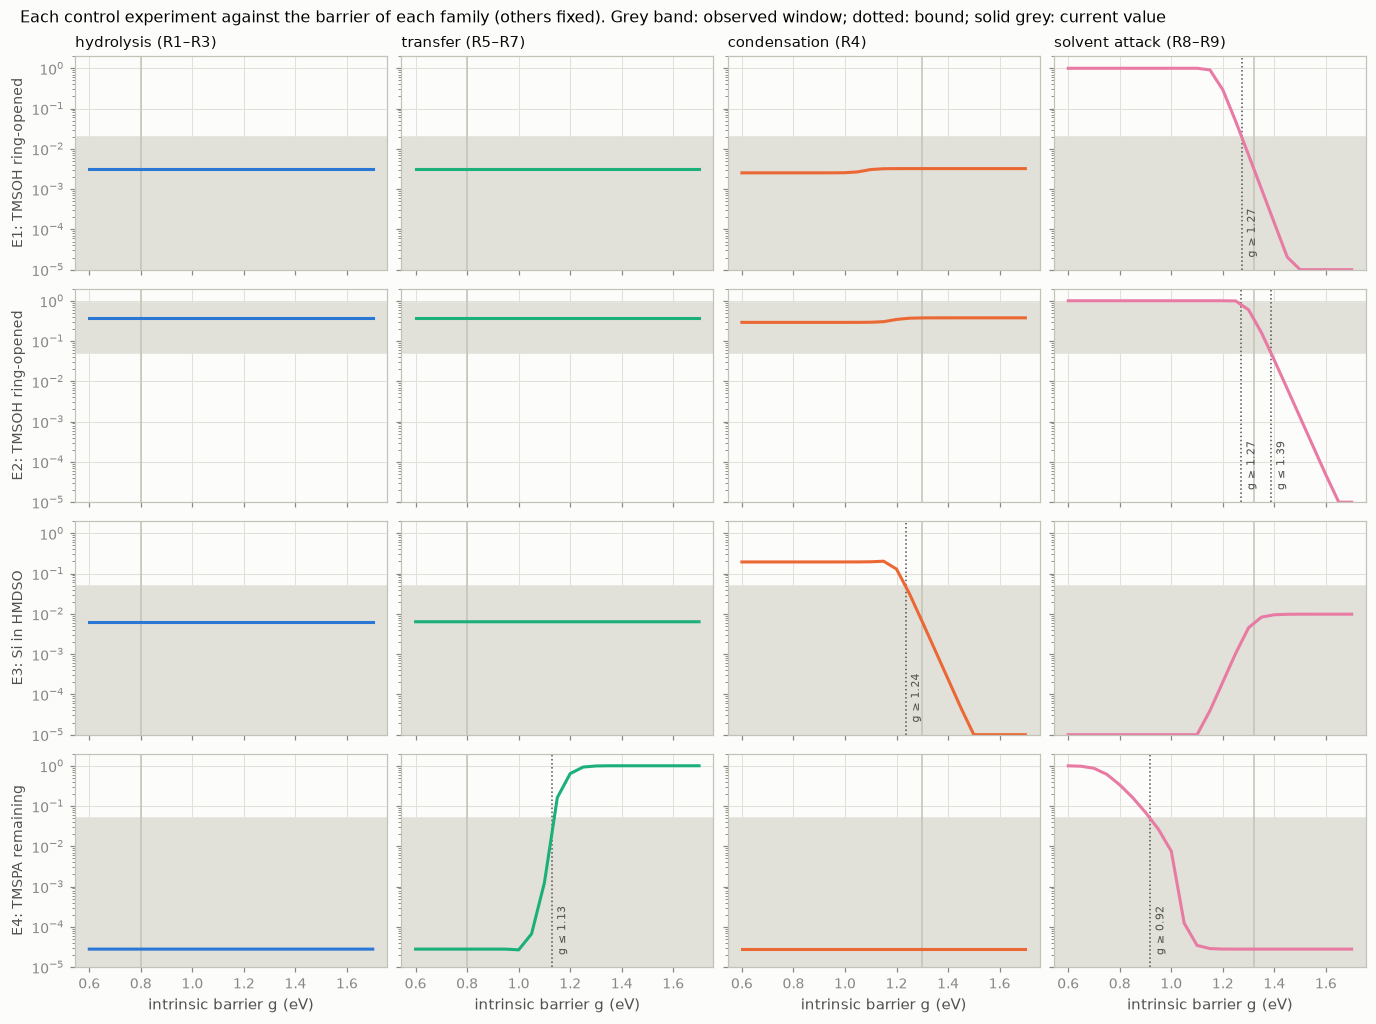

In [5]:
scan = scan_family_barriers(model)
bounds = find_barrier_bounds(model, scan=scan)
intervals = summarize_feasible_intervals(bounds, scan, model)

display(tables.format_columns(bounds.drop(columns='window edge'),
                              {'g_eV': '.3f', 'T_K': '.0f', 'dG_barrier_at_bound_eV': '.3f'}))
display(tables.format_columns(intervals, {'g low (eV)': '.3f', 'g high (eV)': '.3f', 'current g (eV)': '.2f'}))
design_plots.plot_feasibility_scan(scan, bounds, {f: get_family_parameter(model, f) for f in FAMILIES});

**Reading.**
- **Solvent attack is bounded on both sides:** g = 1.27–1.39 eV, from no ring-opening at 25 °C (E1) and partial ring-opening after 8 h at 80 °C (E2). As an observed barrier this is ΔG‡(R8) = 1.25–1.36 eV at 80 °C.
- **Condensation has only a lower bound:** g ≥ 1.24 eV, i.e. ΔG‡(R4) ≥ 1.29 eV at 80 °C. It comes from E3, whose 5 % detection limit is assumed. Faster condensation would have produced visible HMDSO from TMSOH alone.
- **Transfer has only an upper bound:** g ≤ 1.13 eV, i.e. ΔG‡(R5) ≤ 0.95 eV at 25 °C. It comes from E4, whose 24 h reaction time is assumed. Any faster value is equally consistent.
- **Hydrolysis is untouched:** its column is flat in every row, because none of the controls contains water.
- One indirect bound appears: solvent attack ≥ 0.92 eV from E4, because below that EC would eat the TMSOH before it can react with TMSPA. It is irrelevant given E1.

### 3.1 How firm are the bounds?

Three of the windows rest on a detection limit or a reaction time the paper does not state. Each assumption is varied and the bound it sets is recomputed.

In [6]:
controls = {e['id']: e for e in load_experimental_data()['control_experiments']}

def vary_control(exp_id, **changes):
    e = copy.deepcopy(controls[exp_id])
    e.update(changes)
    return e

ASSUMPTIONS = [
    ('condensation', 'E3: HMDSO below 2 % after 8 h at 80 °C', vary_control('E3', high=0.02)),
    ('condensation', 'E3: HMDSO below 5 % (file)', controls['E3']),
    ('condensation', 'E3: HMDSO below 10 %', vary_control('E3', high=0.10)),
    ('transfer', 'E4: TMSPA ≥ 95 % consumed within 1 h', vary_control('E4', t_s=3600)),
    ('transfer', 'E4: within 24 h (file)', controls['E4']),
    ('transfer', 'E4: within 1 week', vary_control('E4', t_s=604800)),
    ('solvent_attack', 'E2: 5–90 % ring-opened after 8 h at 80 °C (file)', controls['E2']),
    ('solvent_attack', 'E2: 20–60 % ring-opened', vary_control('E2', low=0.20, high=0.60)),
    ('solvent_attack', 'E1: below 2 % at RT in 1 week (file)', controls['E1']),
    ('solvent_attack', 'E1: below 10 %', vary_control('E1', high=0.10)),
]
rows = []
for family, assumption, experiment in ASSUMPTIONS:
    found = find_barrier_bounds(model, [family], experiments=[experiment])
    found = found[found['acts'] == 'directly']
    rows.append({'family': family, 'assumption': assumption,
                 'bounds on g (eV)': ';  '.join(f"{b['bound']} {b['g_eV']:.3f}" for _, b in found.iterrows())})
robustness = pd.DataFrame(rows)
robustness

,family,assumption,bounds on g (eV)
0,condensation,E3: HMDSO below 2 % after 8 h at 80 °C,g ≥ 1.265
1,condensation,E3: HMDSO below 5 % (file),g ≥ 1.235
2,condensation,E3: HMDSO below 10 %,g ≥ 1.210
3,transfer,E4: TMSPA ≥ 95 % consumed within 1 h,g ≤ 1.046
4,transfer,E4: within 24 h (file),g ≤ 1.129
5,transfer,E4: within 1 week,g ≤ 1.179
6,solvent_attack,E2: 5–90 % ring-opened after 8 h at 80 °C (file),g ≤ 1.387; g ≥ 1.271
7,solvent_attack,E2: 20–60 % ring-opened,g ≤ 1.343; g ≥ 1.299
8,solvent_attack,E1: below 2 % at RT in 1 week (file),g ≥ 1.273
9,solvent_attack,E1: below 10 %,g ≥ 1.230


**Reading.**
- **The bounds move by 0.03–0.08 eV with the assumptions behind them.**
  - Condensation: the lower bound runs from 1.21 to 1.27 eV as the detection limit goes from 10 % to 2 %.
  - Transfer: the upper bound runs from 1.05 eV (reaction within 1 h) to 1.18 eV (within 1 week).
  - Solvent attack: the interval narrows to 1.30–1.34 eV if 20–60 % ring-opening is assumed.
- **The unknown times and detection limits cost about as much as the bounds are wide.** Asking the authors for the E4 reaction time, or finding it in the SI, would tighten transfer for free.

### 3.2 What two temperatures say about ΔS‡

An observation fixes g at its own temperature: g(T) = g(25 °C) − (T − 25 °C)·ΔS‡. For solvent attack, E1 (25 °C) and E2 (80 °C) therefore constrain a region in the (ΔS‡, g) plane, not a single value.

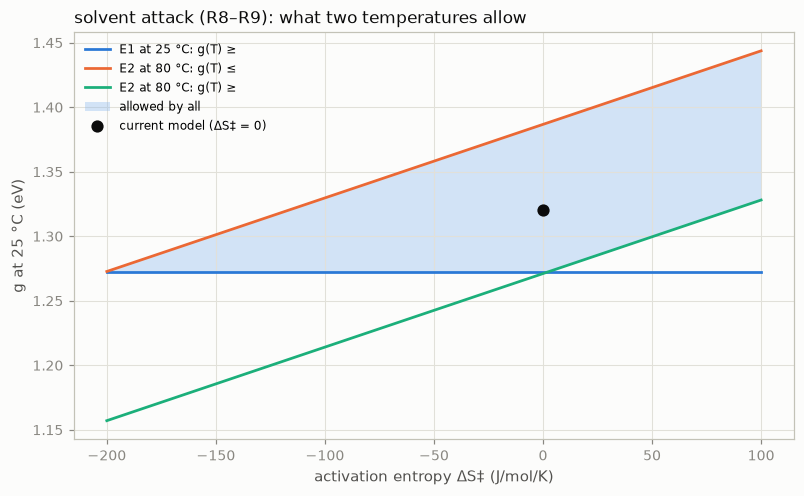

In [7]:
projection = project_bounds_to_entropy(bounds[bounds['acts'] == 'directly'], 'solvent_attack',
                                       np.arange(-200.0, 101.0, 10.0))
design_plots.plot_entropy_constraints(projection, 'solvent_attack',
                                      current=(0.0, get_family_parameter(model, 'solvent_attack')));

**Reading.**
- One temperature fixes one combination of g and ΔS‡. E1 (25 °C) bounds g at 25 °C directly, while E2 (80 °C) bounds a line whose slope is the 55 K between the experiments.
- Together they only exclude ΔS‡ below about −200 J/mol/K. Any ΔS‡ from −200 to +100 J/mol/K is allowed, with g at 25 °C between 1.27 and 1.44 eV.
- This is the situation for every family: **to learn ΔS‡, the same step must be measured quantitatively at two or more temperatures** (§7.4).

## 4. Where the model fails: TMSPA with water

Gogoi 2024 also report ³¹P of TMSPA in EC/DEC with four water contents, recorded at an unstated time after mixing, and the 2 vol% sample heated to 80 °C. The windows below are our reading of their text (status `reading`). Because the time is unknown, a parameter set passes only if **one common time** satisfies every sample. The hydrolysis and transfer barriers are varied over and beyond the range the controls allow.

,id,h2o_vol_pct,observation,windows,status
0,W0.5,0.5,"strong TMSPA at -24.60 ppm, weak BMSPA (Fig. 1a)","{'TMSPA': [0.5, None]}",reading
1,W1,1.0,reaction stops at BMSPA while most TMSPA remains unreacted (text only),"{'TMSPA': [0.5, None], 'MMSPA+H3PO4': [None, 0.1]}",reading
2,W2,2.0,"no TMSPA; BMSPA, MMSPA and a strong H3PO4 signal (Fig. 1b)","{'TMSPA': [None, 0.05], 'H3PO4': [0.3, None], 'BMSPA+MMSPA': [0.1, None]}",reading
3,W5,5.0,H3PO4 and a very weak MMSPA signal (Fig. 1c),"{'H3PO4': [0.8, None]}",reading


Parameter sets with at least one common time that satisfies the samples:


,0.5 and 1 vol%,2 and 5 vol%,1 and 2 vol%,all four
sets passing (of 21),15,8,0,0


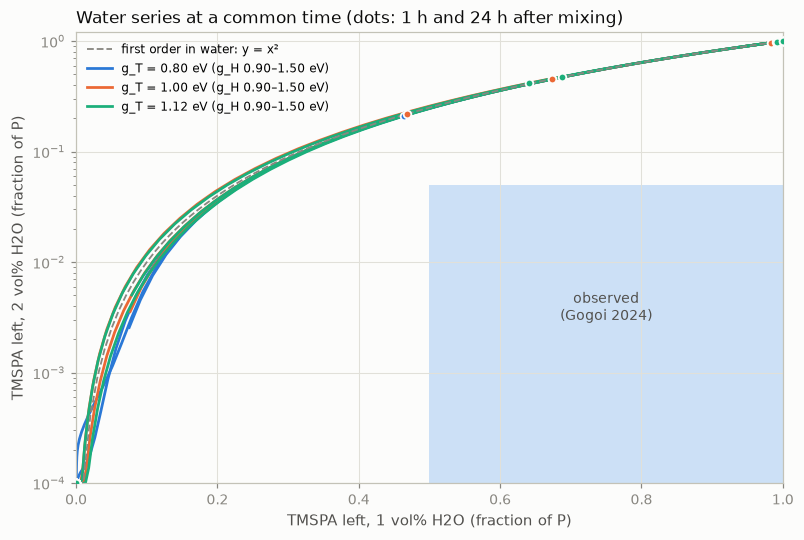

In [8]:
water_series = get_water_series()
display(pd.DataFrame(water_series['samples'])[['id', 'h2o_vol_pct', 'observation', 'windows', 'status']])

G_H_GRID = (0.90, 1.00, 1.10, 1.20, 1.30, 1.40, 1.50)
G_T_GRID = (0.80, 1.00, 1.12)
candidates = [model.with_family_params('hydrolysis', g_eV=gH)
                   .with_family_params('transfer', g_eV=gT, name=f'g_H {gH:.2f}, g_T {gT:.2f}')
              for gT in G_T_GRID for gH in G_H_GRID]
water = evaluate_water_series(candidates, method='BDF')

pairs = {'0.5 and 1 vol%': ['W0.5 ok', 'W1 ok'], '2 and 5 vol%': ['W2 ok', 'W5 ok'],
         '1 and 2 vol%': ['W1 ok', 'W2 ok'], 'all four': ['W0.5 ok', 'W1 ok', 'W2 ok', 'W5 ok']}
water_summary = pd.DataFrame({
    label: water.assign(ok=water[cols].all(axis=1)).groupby('model', sort=False)['ok'].any()
    for label, cols in pairs.items()
})
print('Parameter sets with at least one common time that satisfies the samples:')
display(water_summary.sum().to_frame('sets passing (of %d)' % len(water_summary)).T)

groups = {m.name: f"g_T = {m.name.split('g_T ')[1]} eV (g_H 0.90–1.50 eV)" for m in candidates}
design_plots.plot_water_series_check(water, groups=groups);

In [9]:
heating = evaluate_heating_observation(candidates, rt_hold_h=(1.0, 6.0, 24.0))
consistent_rt = heating[heating['RT ok']]
print(f"{len(consistent_rt)} of {len(heating)} runs give Gogoi's RT spectrum; "
      f"{int(consistent_rt['heating ok'].sum())} of those keep it unchanged up to 80 °C.")
heating_view = consistent_rt.drop(columns=['RT ok'])
tables.format_columns(heating_view, {c: '.2f' for c in heating_view.columns if c.startswith(('RT ', '80 °C', 'max'))})

4 of 63 runs give Gogoi's RT spectrum; 0 of those keep it unchanged up to 80 °C.


,model,RT hold (h),RT TMSPA,RT BMSPA,RT MMSPA,RT H3PO4,80 °C TMSPA,80 °C BMSPA,80 °C MMSPA,80 °C H3PO4,max change,heating ok
7,"g_H 1.10, g_T 0.80",6.00,0.00,0.33,0.25,0.41,0.00,0.00,0.00,1.00,0.59,False
8,"g_H 1.10, g_T 0.80",24.00,0.00,0.02,0.10,0.88,0.00,0.00,0.00,1.00,0.12,False
28,"g_H 1.10, g_T 1.00",6.00,0.00,0.35,0.29,0.36,0.00,0.00,0.00,1.00,0.64,False
50,"g_H 1.10, g_T 1.12",24.00,0.00,0.11,0.16,0.73,0.00,0.00,0.00,1.00,0.27,False


**Reading.**
- **The model cannot reproduce the water series at any barrier values, at a common time:**
  - The low-water pair (0.5 and 1 vol%: TMSPA survives) is reproduced only for hydrolysis g ≥ 1.10 eV.
  - The high-water pair (2 and 5 vol%: no TMSPA, mostly H₃PO₄) is reproduced only for g ≤ 1.10 eV.
  - At g = 1.10 eV the low pair holds only in the first minute and the high pair only after 6–30 h.

  Transfer does not change this.
- **The figure shows why.** Every barrier traces the same curve, close to y = x²: when the rate is first order in water, TMSPA left at 2 vol% is the square of TMSPA left at 1 vol%, whatever g is. Gogoi's two samples lie far below that curve, as a threshold between 1 and 2 vol%.
- **The heating observation fails too.** Of the 63 runs, 4 give Gogoi's room-temperature spectrum at 2 vol%, and all 4 drive the remaining BMSPA and MMSPA to H₃PO₄ by 80 °C. Gogoi saw no change.
- **What could explain it.** Each hypothesis predicts a different signature in the time-resolved experiments C and D:

| hypothesis | meaning | signature in C and D |
|---|---|---|
| unequal sampling times | the 1 vol% sample was measured earlier | none: D starts exactly 4× slower than C |
| rate law not first order in water | e.g. acid catalysis by the P–OH products, or water aggregation | sigmoidal TMSPA decay (induction period) in C; D much more than 4× slower |
| equilibrium, or wrong ΔG_rxn (SLV-01) | the ladder stops where equilibrium lies | plateaus that stop moving in time and shift with the water content |
| water unavailable | phase separation (DEC is poorly miscible with water) or water consumed by EC above 40 °C | Karl Fischer after the run and the ¹H mass balance (NB02 §6) show water missing |

- **Consequence.** Fitting only a hydrolysis barrier to the first data set would be premature. Experiments C and D are chosen so that these hypotheses can be told apart.

## 5. What the planned step protocol would show

Peter's protocol (§ NB02) under the hydrolysis barriers the data still allow: TMSPA left at each acquisition.

hold T (°C),20.0,30.0,40.0,50.0,60.0,70.0,80.0
g_H = 1.00 eV,0.000,0.000,0.000,0.000,0.000,0.0,0.0
g_H = 1.10 eV,0.000,0.000,0.000,0.000,0.000,0.0,0.0
g_H = 1.20 eV,0.001,0.000,0.000,0.000,0.000,0.0,0.0
g_H = 1.25 eV,0.365,0.008,0.000,0.000,0.000,0.0,0.0
g_H = 1.30 eV,0.865,0.501,0.065,0.000,0.000,0.0,0.0
g_H = 1.35 eV,0.980,0.902,0.649,0.193,0.000,0.0,0.0
g_H = 1.40 eV,0.997,0.985,0.934,0.758,0.353,0.0,0.0


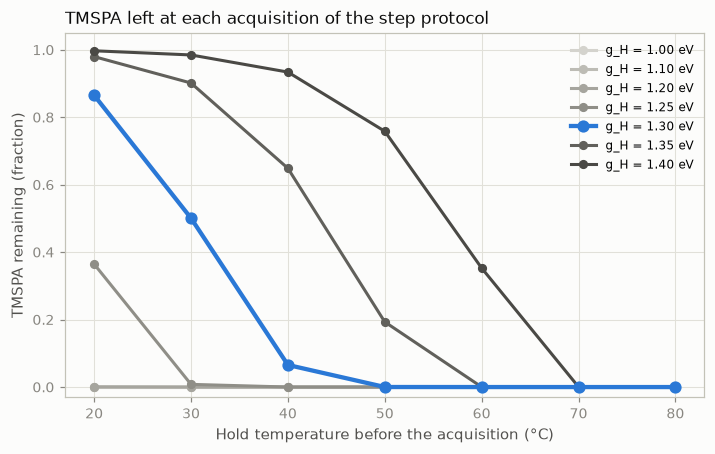

In [10]:
recipe = calculate_recipe_molarities(h2o_vol_frac_stock=0.02, tmspa_vol_frac=0.05)
stages, _ = build_protocol_schedule()
protocol_sweep = {f'g_H = {g:.2f} eV': simulate_protocol(stages, recipe, model=model.with_family_params('hydrolysis', g_eV=g))
                  for g in (1.00, 1.10, 1.20, 1.25, 1.30, 1.35, 1.40)}
display((pd.DataFrame({name: calculate_remaining_fraction(sim) for name, sim in protocol_sweep.items()}).T
         .round(3) + 0.0))
ax = reactor_plots.plot_step_depletion(protocol_sweep, highlight='g_H = 1.30 eV',
                                       title='TMSPA left at each acquisition of the step protocol')
ax.legend(loc='upper right', fontsize=8);

**Reading.**
- **The protocol's outcome depends entirely on the unknown hydrolysis barrier.**
  - For g ≤ 1.20 eV every TMSPA is gone before the first acquisition (after 8 h at 20 °C), and the series shows only the end of the ladder.
  - For g = 1.25–1.40 eV consumption spreads over the holds, which is the regime Peter's E0 = 1.15 eV was tuned to under the capped BEP.
- **It records no spectrum between mixing and the end of the first 8 h hold**, where R1 happens for most of the allowed range.
- **Its acquisitions are at 20 °C.** Pure EC melts at 36.4 °C, so either the sample supercools reliably or the spectra must be recorded at ≥ 40 °C.

## 6. How to measure: readouts, noise and timing

### 6.1 What each nucleus reads

The peak groups each nucleus can integrate and the acquisition assumed for each. **These are assumptions to confirm with the NMR facility**; everything in §7 scales with them.

In [11]:
readout_table = pd.DataFrame([
    {'nucleus': n, 'peak': label,
     'species (nuclei per molecule)': ', '.join(f'{sp} ×{k}' for sp, k in members.items()),
     'one spectrum every (min)': DEFAULT_ACQUISITION[n]['interval_h'] * 60.0,
     'σ per integral (mM)': DEFAULT_ACQUISITION[n]['sigma_mM'],
     'why': DEFAULT_ACQUISITION[n]['note']}
    for n, peaks in NMR_READOUTS.items() for label, members in peaks.items()
])
readout_table

,nucleus,peak,species (nuclei per molecule),one spectrum every (min),σ per integral (mM),why
0,P,TMSPA,TMSPA ×1,5.0,1.0,100 % abundant and sensitive; quantitative 1D spectrum in about 5 min if T1 is a few seconds
1,P,BMSPA,BMSPA ×1,5.0,1.0,100 % abundant and sensitive; quantitative 1D spectrum in about 5 min if T1 is a few seconds
2,P,MMSPA,MMSPA ×1,5.0,1.0,100 % abundant and sensitive; quantitative 1D spectrum in about 5 min if T1 is a few seconds
3,P,H3PO4,H3PO4 ×1,5.0,1.0,100 % abundant and sensitive; quantitative 1D spectrum in about 5 min if T1 is a few seconds
4,Si,xMSPA,"TMSPA ×3, BMSPA ×2, MMSPA ×1",30.0,5.0,"4.7 % abundant, long T1, negative NOE: inverse-gated quantitative spectra need about 30 min"
5,Si,TMSOH + TMS-glycols,"TMSOH ×1, TMSOEG ×1, TMSOdiEG ×1",30.0,5.0,"4.7 % abundant, long T1, negative NOE: inverse-gated quantitative spectra need about 30 min"
6,Si,HMDSO,HMDSO ×2,30.0,5.0,"4.7 % abundant, long T1, negative NOE: inverse-gated quantitative spectra need about 30 min"
7,C,CO2,CO2 ×1,60.0,5.0,1.1 % abundant: quantitative spectra need about 1 h
8,C,TMSOEG CH2,TMSOEG ×2,60.0,5.0,1.1 % abundant: quantitative spectra need about 1 h
9,C,TMSOdiEG CH2,TMSOdiEG ×4,60.0,5.0,1.1 % abundant: quantitative spectra need about 1 h


**Reading.**
- **³¹P is the workhorse.** It resolves all four phosphates, one P each, and quantitative spectra take minutes.
- **²⁹Si is needed for the silicon balance.** HMDSO against TMSOH tells transfer from hydrolysis. But the three silyl phosphates share one band, and each quantitative spectrum is slow; a relaxation agent could shorten it, if it is chemically inert here.
- **¹³C sees the ring-opening products**, but only on the scale of hours.
- **¹H is not used for kinetics:** all OH protons exchange into one peak. If its TMS methyl signals are resolved, ¹H would be about 100× more sensitive than ²⁹Si. That would allow millimolar concentrations for fast steps (§6.2).

### 6.2 When the reaction happens

The half-life of TMSPA over the barriers still allowed and the temperatures where pure EC is liquid (≥ 40 °C). Measurable means between the first spectrum (10 min after mixing) and a 12 h run.

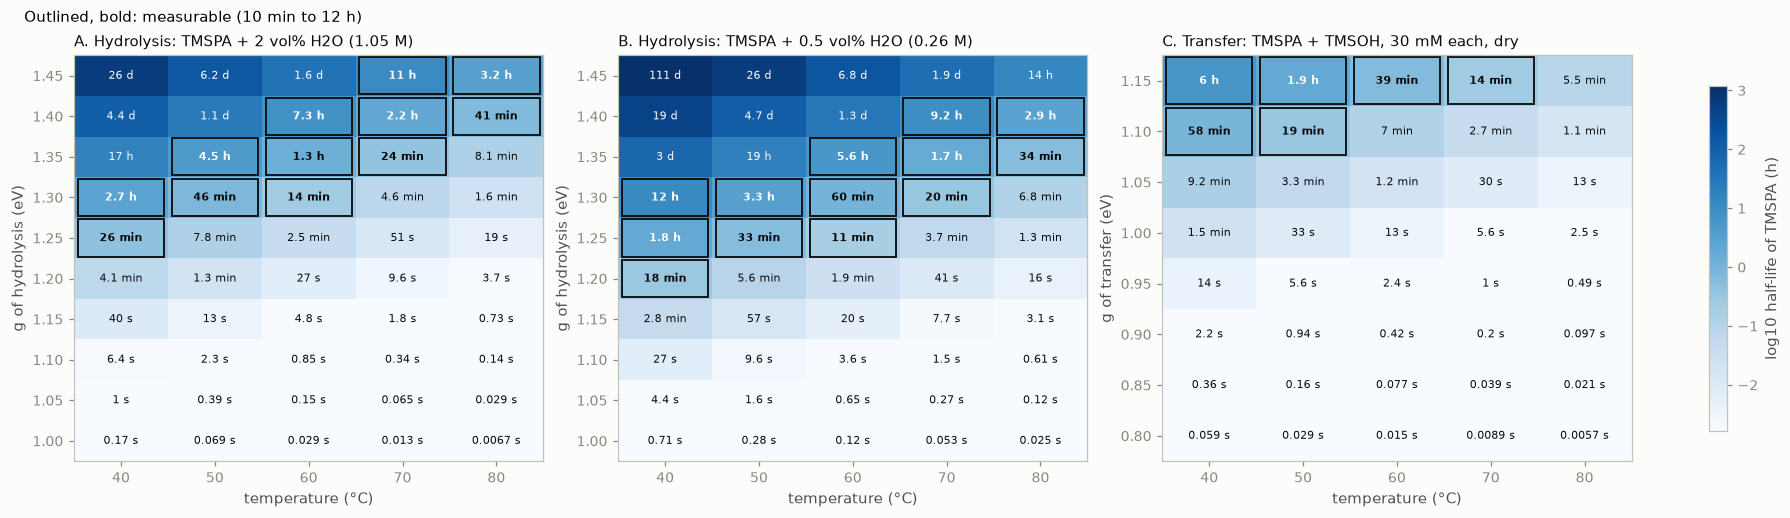

In [12]:
wet = calculate_recipe_molarities(0.02, 0.05)['after']
low = calculate_recipe_molarities(0.005, 0.05)['after']
EC_DRY_M = 1000.0 * DEFAULT_DENSITY_G_ML['EC'] / calculate_molar_mass('EC')   # pure EC, ≈ 15.0 M
c_wet = build_composition(wet['EC'], TMSPA=wet['TMSPA'], H2O=wet['H2O'])
c_low = build_composition(low['EC'], TMSPA=low['TMSPA'], H2O=low['H2O'])
c_dry_transfer = build_composition(EC_DRY_M, TMSPA=0.03, TMSOH=0.03)
c_tmsoh = build_composition(EC_DRY_M, TMSOH=0.45)

T_LIST_C = (40, 50, 60, 70, 80)
half_life_maps = {
    f"A. Hydrolysis: TMSPA + 2 vol% H2O ({wet['H2O']:.2f} M)": calculate_half_life_map(
        model, c_wet, family='hydrolysis', g_values_eV=np.round(np.arange(1.00, 1.451, 0.05), 2), T_C_values=T_LIST_C),
    f"B. Hydrolysis: TMSPA + 0.5 vol% H2O ({low['H2O']:.2f} M)": calculate_half_life_map(
        model, c_low, family='hydrolysis', g_values_eV=np.round(np.arange(1.00, 1.451, 0.05), 2), T_C_values=T_LIST_C),
    'C. Transfer: TMSPA + TMSOH, 30 mM each, dry': calculate_half_life_map(
        model, c_dry_transfer, family='transfer', g_values_eV=np.round(np.arange(0.80, 1.151, 0.05), 2),
        T_C_values=T_LIST_C),
}
for title, table in half_life_maps.items():
    table.index.name = 'g of hydrolysis (eV)' if 'Hydrolysis' in title else 'g of transfer (eV)'
design_plots.plot_half_life_maps(half_life_maps, window_h=(1.0 / 6.0, 12.0));

**Reading.**
- **With 2 vol% water (A), TMSPA hydrolysis is measurable only in a narrow band.** At 40 °C that is g = 1.25–1.30 eV; stepping up to 80 °C extends the window to 1.45 eV. Below 1.20 eV TMSPA is gone within minutes at any temperature where EC is liquid.
- **A quarter of the water (B) makes hydrolysis 4× slower.** That shifts the window by about 0.04 eV, to 1.20–1.30 eV at 40 °C.
  - If the first run shows TMSPA gone at the first spectrum, the next run must use far less water, roughly tenfold per 0.06 eV.
  - The only hint so far is Gogoi's 0.5 vol% sample, where TMSPA survives at room temperature. If it was measured an hour or more after mixing, that suggests g ≳ 1.2 eV.
- **Dry transfer at 30 mM (C) is measurable only if g ≥ 1.10 eV.** For the `level1` value (0.80 eV) the half-life is well below a second. Lowering the concentration is the only lever, because EC cannot be cooled below 36 °C, and that needs a more sensitive readout (¹H).
- **Consequence.** The first run should start at 40 °C, record its first spectrum within 10 min, and then step up. The composition of the next run is then chosen from what the first shows.

## 7. Which experiment determines what

Six candidate experiments. For each, the Fisher information gives the smallest σ a fit of its readouts could reach, if the model were right. The hydrolysis family is split into one barrier per step (R1, R2, R3), so that no design gets credit for the Marcus spacing between the steps: a step is only determined if the data see it happen. σ is judged against two lines: below about 2 meV the systematic errors of §7.3 dominate; above 100 meV the parameter is not determined (the regularising prior is 300 meV).

In [13]:
DESIGNS = [
    build_step_design('A_step_protocol', "Peter's protocol: holds 20…80 °C, spectra at 20 °C", c_wet,
                      hold_temps_C=(20, 30, 40, 50, 60, 70, 80), purpose='reference'),
    build_isothermal_design('B_wet_40C', 'TMSPA + 2 vol% H2O, in situ at 40 °C', c_wet, T_C=40, duration_h=8,
                            purpose='hydrolysis ladder'),
    build_in_situ_design('C_wet_ramp', 'TMSPA + 2 vol% H2O, in situ 40 → 60 → 80 °C', c_wet,
                         segments=((40, 8), (60, 8), (80, 8)), purpose='hydrolysis ladder, every step'),
    build_isothermal_design('D_low_water_40C', 'TMSPA + 0.5 vol% H2O, in situ at 40 °C', c_low, T_C=40,
                            duration_h=8, purpose='order in water'),
    build_isothermal_design('E_dry_transfer_40C', 'TMSPA + TMSOH, 30 mM each, dry, in situ at 40 °C',
                            c_dry_transfer, T_C=40, duration_h=8, purpose='transfer'),
    build_isothermal_design('F_tmsoh_80C', 'TMSOH 0.45 M, dry, in situ at 80 °C', c_tmsoh, T_C=80, duration_h=24,
                            nuclei=('Si', 'C'), purpose='condensation and solvent attack'),
]
display(describe_designs(DESIGNS))

split_model, split_network, HYDROLYSIS_STEPS = split_family_by_reaction(model, 'hydrolysis')
PARAMETERS = HYDROLYSIS_STEPS + ['transfer', 'condensation', 'solvent_attack']
print('Fitted parameters:', ', '.join(PARAMETERS))

,experiment,purpose,solutes at t = 0,temperature program,spectra,first spectrum (min),duration (h)
A_step_protocol,"Peter's protocol: holds 20…80 °C, spectra at 20 °C",reference,"TMSPA 149 mM, H2O 1052 mM","holds 20…80 °C × 8 h, spectra at 20 °C","P: 7, Si: 7, C: 7",540,63.0
B_wet_40C,"TMSPA + 2 vol% H2O, in situ at 40 °C",hydrolysis ladder,"TMSPA 149 mM, H2O 1052 mM",40 °C × 8 h,"P: 95, Si: 16",10,8.0
C_wet_ramp,"TMSPA + 2 vol% H2O, in situ 40 → 60 → 80 °C","hydrolysis ladder, every step","TMSPA 149 mM, H2O 1052 mM",40 °C × 8 h → 60 °C × 8 h → 80 °C × 8 h,"P: 287, Si: 48",10,24.0
D_low_water_40C,"TMSPA + 0.5 vol% H2O, in situ at 40 °C",order in water,"TMSPA 149 mM, H2O 263 mM",40 °C × 8 h,"P: 95, Si: 16",10,8.0
E_dry_transfer_40C,"TMSPA + TMSOH, 30 mM each, dry, in situ at 40 °C",transfer,"TMSPA 30 mM, TMSOH 30 mM",40 °C × 8 h,"P: 95, Si: 16",10,8.0
F_tmsoh_80C,"TMSOH 0.45 M, dry, in situ at 80 °C",condensation and solvent attack,TMSOH 450 mM,80 °C × 24 h,"Si: 48, C: 24",10,24.0


Fitted parameters: hydrolysis_R1, hydrolysis_R2, hydrolysis_R3, transfer, condensation, solvent_attack


### 7.1 Precision over the plausible truths

Left three panels: every hydrolysis step at the same true g, from 1.00 to 1.40 eV. Right panel: transfer from 0.80 to 1.10 eV, with hydrolysis at 1.25 eV.

σ (meV) at true g_H =               1.00   1.10   1.20   1.25   1.30   1.35  \
parameter      design                                                         
condensation   A_step_protocol     300.0  259.1   17.4    8.1   13.5   66.0   
               B_wet_40C           300.0  277.4  299.8  299.6  295.2  263.3   
               C_wet_ramp          300.0   92.2    4.0    2.3    4.3   14.7   
               D_low_water_40C     300.0  299.9  300.0  299.9  297.2  299.8   
               E_dry_transfer_40C  300.0  300.0  300.0  300.0  300.0  300.0   
               F_tmsoh_80C           6.2    6.2    6.2    6.2    6.2    6.2   
hydrolysis_R1  A_step_protocol     300.0  154.5    7.7    0.3    0.3    0.3   
               B_wet_40C           299.1   15.7    0.3    0.1    0.1    0.2   
               C_wet_ramp          299.0   15.4    0.3    0.1    0.0    0.1   
               D_low_water_40C     201.6   12.6    0.1    0.1    0.2    0.3   
               E_dry_transfer_40C  300.0  300.0  300.0  300.0  300.0  300.0   
               F_tmsoh_80C         300.0  300.0  300.0  300.0  300.0  300.0   
hydrolysis_R2  A_step_protocol      38.9    4.6    1.1    0.9    1.0   64.0   
               B_wet_40C             6.8    0.6    1.5    9.2   56.3  271.5   
               C_wet_ramp            6.8    0.6    0.2    0.1    0.6   14.2   
               D_low_water_40C       4.1    0.5    3.3   14.8  193.8  299.8   
               E_dry_transfer_40C  300.0  300.0  300.0  300.0  300.0  300.0   
               F_tmsoh_80C         300.0  300.0  300.0  300.0  300.0  300.0   
hydrolysis_R3  A_step_protocol       3.2    1.7    2.1    3.3   16.1  201.9   
               B_wet_40C             1.2    0.6    6.8  188.8  300.0  300.0   
               C_wet_ramp            1.1    0.5    0.4    0.7    3.3   39.4   
               D_low_water_40C       1.7    0.8  126.0  300.0  300.0  300.0   
               E_dry_transfer_40C  300.0  300.0  300.0  300.0  300.0  300.0   
               F_tmsoh_80C         300.0  300.0  300.0  300.0  300.0  300.0   
solvent_attack A_step_protocol       0.2    0.2    0.5    0.7    1.4    5.9   
               B_wet_40C           271.8  215.4  299.9  300.0  300.0  300.0   
               C_wet_ramp            3.8    3.8    1.6    1.3    5.1   20.8   
               D_low_water_40C      96.5  292.5  300.0  300.0  300.0  300.0   
               E_dry_transfer_40C  300.0  300.0  300.0  300.0  300.0  300.0   
               F_tmsoh_80C           0.1    0.1    0.1    0.1    0.1    0.1   
transfer       A_step_protocol     294.9  290.6  298.5  297.7  299.8  300.0   
               B_wet_40C           106.9   48.3   88.2  202.8  290.4  299.7   
               C_wet_ramp          106.8   48.2   67.7  183.1  278.9  297.4   
               D_low_water_40C     176.7   86.7  189.8  283.3  299.4  300.0   
               E_dry_transfer_40C  271.2  271.2  271.2  271.2  271.2  271.2   
               F_tmsoh_80C         300.0  300.0  300.0  300.0  300.0  300.0   

σ (meV) at true g_H =               1.40  
parameter      design                     
condensation   A_step_protocol      27.4  
               B_wet_40C           298.4  
               C_wet_ramp           20.7  
               D_low_water_40C     300.0  
               E_dry_transfer_40C  300.0  
               F_tmsoh_80C           6.2  
hydrolysis_R1  A_step_protocol       0.3  
               B_wet_40C             0.5  
               C_wet_ramp            0.1  
               D_low_water_40C       1.7  
               E_dry_transfer_40C  300.0  
               F_tmsoh_80C         300.0  
hydrolysis_R2  A_step_protocol     164.7  
               B_wet_40C           300.0  
               C_wet_ramp          111.1  
               D_low_water_40C     300.0  
               E_dry_transfer_40C  300.0  
               F_tmsoh_80C         300.0  
hydrolysis_R3  A_step_protocol     260.0  
               B_wet_40C           300.0  
               C_wet_ramp          214.0  
        

σ of transfer (meV) at true g_T =,0.8,0.9,1.0,1.1
design,,,,
A_step_protocol,297.7,15.1,15.8,1.8
B_wet_40C,202.8,9.8,25.0,1.2
C_wet_ramp,183.1,5.9,2.2,0.7
D_low_water_40C,283.3,27.3,45.2,1.7
E_dry_transfer_40C,271.2,17.1,3.4,0.5
F_tmsoh_80C,300.0,300.0,300.0,300.0


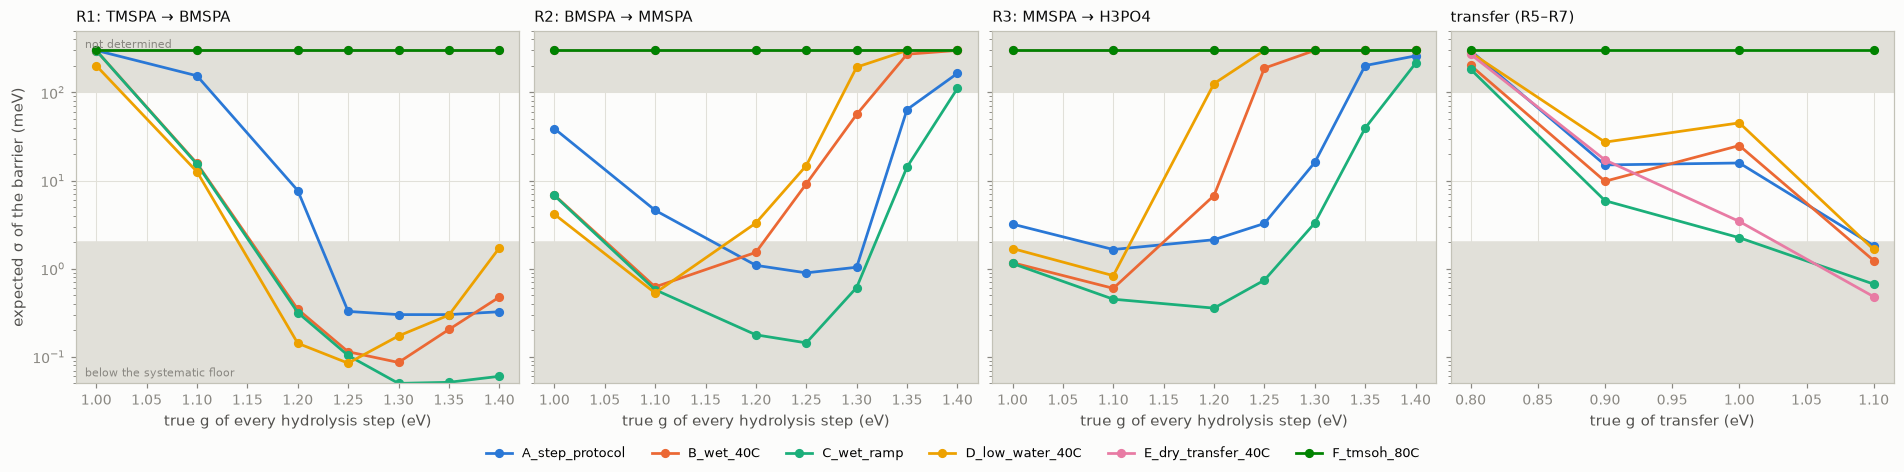

In [14]:
TRUE_G_H = (1.00, 1.10, 1.20, 1.25, 1.30, 1.35, 1.40)
precision_h = scan_design_precision(DESIGNS, split_model, PARAMETERS, vary=HYDROLYSIS_STEPS, values=TRUE_G_H,
                                    network=split_network)
REFERENCE_TRUTH = split_model
for step in HYDROLYSIS_STEPS:
    REFERENCE_TRUTH = REFERENCE_TRUTH.with_family_params(step, g_eV=1.25, name='reference truth')
precision_t = scan_design_precision(DESIGNS, REFERENCE_TRUTH, PARAMETERS, vary='transfer',
                                    values=(0.80, 0.90, 1.00, 1.10), network=split_network)

panels = {f'{step.split("_")[1]}: {label}': (precision_h[precision_h['parameter'] == step], 'true g of every hydrolysis step (eV)')
          for step, label in zip(HYDROLYSIS_STEPS, ('TMSPA → BMSPA', 'BMSPA → MMSPA', 'MMSPA → H3PO4'))}
panels['transfer (R5–R7)'] = (precision_t[precision_t['parameter'] == 'transfer'], 'true g of transfer (eV)')
design_plots.plot_design_precision(panels);
display((precision_h.pivot_table(index=['parameter', 'design'], columns='true value', values='sigma') * 1000.0)
        .round(1).rename_axis(columns='σ (meV) at true g_H ='))
display((precision_t[precision_t['parameter'] == 'transfer']
         .pivot_table(index='design', columns='true value', values='sigma') * 1000.0)
        .round(1).rename_axis(columns='σ of transfer (meV) at true g_T ='))

**Reading.**
- **R1 (TMSPA → BMSPA).** Every in-situ wet design (B, C, D) determines it for g ≥ 1.10 eV. The step protocol A needs g ≥ 1.20 eV. For g = 1.00 eV nothing determines it: the step is over within a second. Near g = 1.10 eV the information comes from product ratios after the step (hydrolysis against transfer), not from watching TMSPA decay, so it depends on the model structure.
- **R2 and R3 (the later steps).** The isothermal 40 °C runs (B, D) lose them above 1.20–1.25 eV, because the steps do not happen within 8 h at 40 °C. The ramp C keeps both at or below 3.3 meV up to 1.30 eV and below 40 meV at 1.35 eV. The step protocol A also reaches R2 and R3 up to about 1.30 eV, but misses R1 below 1.20 eV.
- **Transfer.** It is determined only if its true g ≥ 0.9 eV: E by watching it, C by the HMDSO/TMSOH balance. At 0.80 eV no design determines it; E then gives only a sharper upper bound than E4.
- **Condensation and solvent attack.** F determines both. C also informs condensation at 80 °C, through the hydrolysis of HMDSO. C runs in acidic, wet conditions and F in neutral, dry ones, so disagreement between the two values of g would be direct evidence for acid catalysis.

### 7.2 The plan as a whole

σ of every parameter at the reference truth (all hydrolysis steps 1.25 eV, level1 values otherwise) for each design alone and for combinations. Values in meV.

In [15]:
COMBINATIONS = {
    'plan: C + D + E + F': ['C_wet_ramp', 'D_low_water_40C', 'E_dry_transfer_40C', 'F_tmsoh_80C'],
    'plan without ramp: B + D + E + F': ['B_wet_40C', 'D_low_water_40C', 'E_dry_transfer_40C', 'F_tmsoh_80C'],
}
plan_precision = compare_designs(DESIGNS, REFERENCE_TRUTH, PARAMETERS, combinations=COMBINATIONS,
                                 network=split_network) * 1000.0
plan_precision.round(1)

,hydrolysis_R1,hydrolysis_R2,hydrolysis_R3,transfer,condensation,solvent_attack
A_step_protocol,0.3,0.9,3.3,297.7,8.1,0.7
B_wet_40C,0.1,9.2,188.8,202.8,299.6,300.0
C_wet_ramp,0.1,0.1,0.7,183.1,2.3,1.3
D_low_water_40C,0.1,14.8,300.0,283.3,299.9,300.0
E_dry_transfer_40C,300.0,300.0,300.0,271.2,300.0,300.0
F_tmsoh_80C,300.0,300.0,300.0,300.0,6.2,0.1
plan: C + D + E + F,0.0,0.1,0.7,165.8,2.0,0.1
plan without ramp: B + D + E + F,0.1,3.2,181.8,177.8,6.2,0.1


**Reading.**
- **The plan C + D + E + F determines every parameter except transfer** at the reference truth, below or near the systematic floor.
- **Replacing the ramp C by the isothermal B loses R3 entirely** (182 meV). The step to 60 and 80 °C in the same run is what reaches the slow end of the ladder.
- **Transfer stays undetermined** (166 meV) because the reference truth has it at 0.80 eV, too fast to follow at 30 mM. It is the one family where a smaller concentration and a more sensitive readout could change the answer.

### 7.3 Systematic errors and the step from ΔG‡ to g

The Fisher σ counts only the noise of the integrals. The table adds the systematic errors of a run at 40 °C, and the error that the family g inherits from ΔG_rxn (it does not affect the measured ΔG‡ itself).

In [16]:
dG_R1_40C = REFERENCE_TRUTH.calculate_rates(313.15, network=split_network).loc['R1', 'dG_barrier_f_eV']
sigma_solv = calculate_network_thermo(298.15)['sigma_solv_eV']
error_budget = calculate_barrier_error_budget(
    dG_R1_40C, 40.0, dT_K=0.5, rel_conc_error=0.05,
    sigma_dG_rxn_eV={'if the MD σ are standard errors': 0.02,
                     'if the MD σ are raw stds, network median': float(sigma_solv.median())})
print(f'ΔG‡(R1) at 40 °C in the reference truth: {dG_R1_40C:.3f} eV')
error_budget.round(2)

ΔG‡(R1) at 40 °C in the reference truth: 1.024 eV


,on measured ΔG‡ (meV),on family g (meV),factor on k
sample temperature ±0.5 K,1.68,1.68,1.06
initial co-reactant concentration ±5 %,1.32,1.32,1.05
ΔG_rxn ±0.02 eV (if the MD σ are standard errors),0.00,10.00,1.00
"ΔG_rxn ±0.25 eV (if the MD σ are raw stds, network median)",0.00,125.22,1.00


**Reading.**
- **The systematic floor of a measured barrier is about 2 meV.** It comes from ±0.5 K in the sample temperature and ±5 % in the initial water, which is why Karl Fischer is required. Each is a factor of about 1.05 in the rate constant, well above the noise-limited σ of the best designs. **σ below 2 meV in §7.1 means "limited by systematics", not "better".**
- **The family g inherits the ΔG_rxn error.** That is 10 meV if the MD σ are standard errors, but 125 meV if they are raw standard deviations (SLV-01). In the second case the measured ΔG‡ of each step is precise, but the family g, and every prediction that uses the Marcus relation to transfer it to another reaction, is not.
- **Report the fitted ΔG‡ per step as the primary result**, and derive g only once SLV-01 is resolved.

### 7.4 How many temperatures for ΔS‡

Barriers measured at several temperatures, each to ±3 meV (systematic floor plus noise), give ΔH‡ and ΔS‡ by linear regression.

In [17]:
eyring = calculate_eyring_precision({
    'two, 40 and 60 °C': (40, 60),
    'three, 40 to 80 °C': (40, 60, 80),
    'five, 40 to 80 °C': (40, 50, 60, 70, 80),
    'three, 60 to 80 °C': (60, 70, 80),
}, sigma_g_eV=0.003)
tables.format_columns(eyring, {'span (K)': '.0f', 'σ ΔS‡ (J/mol/K)': '.0f', 'σ ΔH‡ (kJ/mol)': '.1f'})

,temperatures (°C),n,span (K),σ ΔS‡ (J/mol/K),σ ΔH‡ (kJ/mol)
"two, 40 and 60 °C","40, 60",2,20,20,6.6
"three, 40 to 80 °C","40, 60, 80",3,40,10,3.4
"five, 40 to 80 °C","40, 50, 60, 70, 80",5,40,9,3.1
"three, 60 to 80 °C","60, 70, 80",3,20,20,7.0


**Reading.**
- **The temperature span matters more than the number of temperatures.** Three temperatures across 40 K give σ(ΔS‡) ≈ 10 J/mol/K and σ(ΔH‡) ≈ 3 kJ/mol. Two temperatures 20 K apart give 20 J/mol/K. Five temperatures on the same span gain little.
- **The ramp C gives the later steps (R2, R3) over two or three temperatures within one run.** R1 reacts only where it is fast enough, so its temperature dependence needs a repeat of C at a second starting temperature (priority 5).

## 8. What the first experiment would look like

Design C for two truths 0.05 eV apart (lines), and one synthetic measurement of the first truth with the assumed noise (dots).

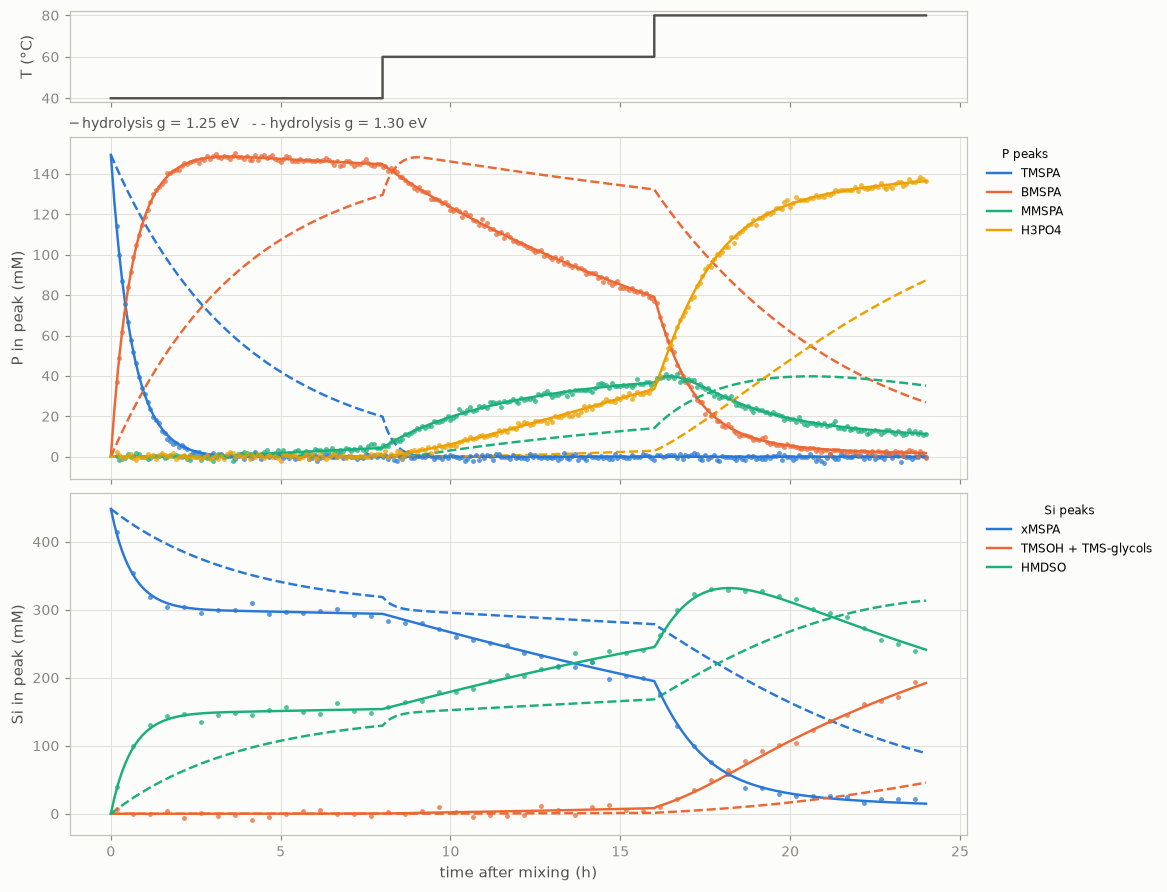

In [18]:
design_c = next(d for d in DESIGNS if d.name == 'C_wet_ramp')
truths = {}
for g in (1.25, 1.30):
    truth = split_model
    for step in HYDROLYSIS_STEPS:
        truth = truth.with_family_params(step, g_eV=g)
    truths[f'hydrolysis g = {g:.2f} eV'] = truth
design_runs = {label: simulate_design(design_c, truth, network=split_network) for label, truth in truths.items()}
synthetic = {label: add_readout_noise(run) for label, run in design_runs.items()}
design_plots.plot_design_readouts(design_runs, synthetic);

**Reading.**
- **At the reference truth (g = 1.25 eV, solid lines):**
  - TMSPA turns into BMSPA within about an hour at 40 °C.
  - BMSPA persists until the 60 °C step turns it into MMSPA and H₃PO₄, and the ladder completes at 80 °C.
  - HMDSO appears together with BMSPA: in this model every TMSOH released is captured at once by transfer, which matches the strong HMDSO line Gogoi saw in the 2 vol% sample.
  - TMSOH and the glycols rise only at 80 °C.
- **A barrier 0.05 eV higher (dashed) shifts every stage visibly.** At the assumed noise the difference is many times the scatter of the points. It is also the kind of data that tests §4: an induction period or a stalled ladder would be obvious by eye.

## 9. Tentative plan

In order of priority. Each experiment has one main target and a built-in control; the decision column says what to change if it fails.

In [19]:
plan = pd.DataFrame([
    ['1', 'C: TMSPA + 2 vol% H2O, in situ 40 → 60 → 80 °C (8 h each)', '³¹P every 5 min, ²⁹Si every 30 min',
     'g of R1, R2, R3 separately; transfer if g_T ≥ 0.9', 'Karl Fischer before and after; t = 0 spectrum'],
    ['2', 'D: same with 0.5 vol% H2O', 'as 1', 'order in water; the water-series threshold (§4)',
     'if R1 is not ~4× slower than in 1, the rate law is wrong'],
    ['3', 'E: TMSPA + TMSOH, 30 mM each, dry, 40 °C', '³¹P every 5 min, ²⁹Si every 30 min',
     'g of transfer, or a tighter upper bound', 'if consumed before the first spectrum: halve the concentration'],
    ['4', 'F: TMSOH 0.45 M, dry, 80 °C, 24 h', '²⁹Si every 30 min, ¹³C every 1 h',
     'condensation and solvent attack, and the E1–E3 windows as curves', 'CO₂ partitions into the headspace'],
    ['5', 'Repeat 1 at a second temperature (from §6.2)', 'as 1', 'ΔH‡, ΔS‡ of each hydrolysis step',
     'choose T so that t½ of the step is 30 min–5 h'],
], columns=['priority', 'experiment', 'nuclei and cadence', 'determines', 'decision / control'])
plan

,priority,experiment,nuclei and cadence,determines,decision / control
0,1,"C: TMSPA + 2 vol% H2O, in situ 40 → 60 → 80 °C (8 h each)","³¹P every 5 min, ²⁹Si every 30 min","g of R1, R2, R3 separately; transfer if g_T ≥ 0.9",Karl Fischer before and after; t = 0 spectrum
1,2,D: same with 0.5 vol% H2O,as 1,order in water; the water-series threshold (§4),"if R1 is not ~4× slower than in 1, the rate law is wrong"
2,3,"E: TMSPA + TMSOH, 30 mM each, dry, 40 °C","³¹P every 5 min, ²⁹Si every 30 min","g of transfer, or a tighter upper bound",if consumed before the first spectrum: halve the concentration
3,4,"F: TMSOH 0.45 M, dry, 80 °C, 24 h","²⁹Si every 30 min, ¹³C every 1 h","condensation and solvent attack, and the E1–E3 windows as curves",CO₂ partitions into the headspace
4,5,Repeat 1 at a second temperature (from §6.2),as 1,"ΔH‡, ΔS‡ of each hydrolysis step",choose T so that t½ of the step is 30 min–5 h


**Questions for Jan Felix (NMR)**
1. Can spectra be recorded in the magnet at 40–80 °C? How soon after mixing can the first one start, and how accurate is the sample temperature (±0.5 K assumed)?
2. Quantitative ³¹P: what are the T₁ of the silyl phosphates in EC? Is one spectrum every 5 min with about 1 mM error per integral realistic?
3. Quantitative ²⁹Si: how long does an inverse-gated spectrum take? Is a relaxation agent (e.g. Cr(acac)₃) acceptable, or could it react? Can TMSOH (≈ 15 ppm) and the TMS glycols (≈ 19 ppm) be resolved?
4. Can ¹H resolve the TMS methyl groups of TMSPA, BMSPA, TMSOH and HMDSO? That would allow millimolar concentrations for the fast transfer step.
5. Can ³¹P and ²⁹Si be interleaved in one run? Which lock and reference (Gogoi used a DMSO-d₆ insert)? Is the tube sealed, and how much headspace does it have (CO₂)?
6. What is the data format: pseudo-2D arrays? We need integrals per peak and per time, with their uncertainties.

**Questions for Erik (samples)**
- Karl Fischer water before adding TMSPA and after the run.
- Purity of the TMSPA batch (Gogoi found BMSPA in "pure" TMSPA).
- Pure EC or EC/DEC? Is the sample one phase?
- The exact reaction time of the TMSPA + TMSOH control (E4).

**What we can already state**
- A single global barrier is excluded.
- Solvent attack needs g = 1.27–1.39 eV.
- Uncatalysed condensation is slow (g ≥ 1.24 eV).
- Transfer is fast at room temperature (g ≤ 1.13 eV).
- Hydrolysis is not constrained, and the existing water-series observations contradict a hydrolysis step that is first order in water in one homogeneous phase.

## 10. Export

Tables of this notebook to `notebooks/results/03/` as CSV (ignored by git).

In [20]:
OUT_DIR = REPO / 'notebooks' / 'results' / '03'
OUT_DIR.mkdir(parents=True, exist_ok=True)
exports = {
    'feasibility_scan.csv': scan,
    'barrier_bounds.csv': bounds,
    'feasible_intervals.csv': intervals,
    'bound_assumptions.csv': robustness,
    'water_series.csv': water,
    'heating_check.csv': heating,
    'design_list.csv': describe_designs(DESIGNS),
    'design_precision_hydrolysis.csv': precision_h,
    'design_precision_transfer.csv': precision_t,
    'plan_precision_meV.csv': plan_precision,
    'error_budget.csv': error_budget,
    'eyring_precision.csv': eyring,
    'plan.csv': plan,
}
for title, table in half_life_maps.items():
    exports[f"half_life_h_{title.split('.')[0]}.csv"] = table
for name, df in exports.items():
    df.to_csv(OUT_DIR / name)
    print(f'notebooks/results/03/{name}: {len(df)} rows')

notebooks/results/03/feasibility_scan.csv: 368 rows
notebooks/results/03/barrier_bounds.csv: 6 rows
notebooks/results/03/feasible_intervals.csv: 4 rows
notebooks/results/03/bound_assumptions.csv: 10 rows
notebooks/results/03/water_series.csv: 2520 rows
notebooks/results/03/heating_check.csv: 63 rows
notebooks/results/03/design_list.csv: 6 rows
notebooks/results/03/design_precision_hydrolysis.csv: 252 rows
notebooks/results/03/design_precision_transfer.csv: 144 rows
notebooks/results/03/plan_precision_meV.csv: 8 rows
notebooks/results/03/error_budget.csv: 4 rows
notebooks/results/03/eyring_precision.csv: 4 rows
notebooks/results/03/plan.csv: 5 rows
notebooks/results/03/half_life_h_A.csv: 10 rows
notebooks/results/03/half_life_h_B.csv: 10 rows
notebooks/results/03/half_life_h_C.csv: 8 rows
